In [6]:
import matplotlib
import pandas as pd
from sqlalchemy import create_engine
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import os

In [7]:
from forecasting.utils.database import read_sql

df = read_sql("""
SELECT *
FROM mart.mart_fresh_food_order_sale
WHERE date >= '2025-11-01'""")
df.head(1)

,flight_key,flight_number,origin,destination,date,month_name,year,weekday_name,is_weekend,hour_of_departure,...,is_night,am_pm,number_of_passengers,item_id,category,price,is_outbound,flight_duration_hours,sold_quantity,potential_error
0,6e687716bee7fa73583d11a912291374,AB401,city_001,city_022,2026-01-23,January,2026.0,Friday,False,22.0,...,True,PM,169.0,PROD_199,Meals,28.0,True,4.42,0.0,NaN


In [8]:
df.to_parquet("../interim_files/raw_data_df.parquet")

Dataset limitations:
- Analysis period covers only 4 months.
- Seasonality cannot be reliably evaluated.
- Results should be treated as preliminary.

## 1. Dataset Cleanup

In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates()

# Check uniqueness of grain (flight_key + item_id)
grain_duplicates = df.duplicated(subset=['flight_key', 'item_id']).sum()
print(f"Duplicate flight_key + item_id combinations: {grain_duplicates}")
df = df.drop_duplicates(subset=['flight_key', 'item_id'])

Number of duplicate rows: 0
Duplicate flight_key + item_id combinations: 0


In [10]:
# Filtering out errors
print(f"Total records: {len(df)}")
print(f"Records with flags: {df['potential_error'].notna().sum()}")
print(f"Clean records (no flags): {df['potential_error'].isna().sum()}")


error_types = df['potential_error'].value_counts(dropna=True)
print(f"Potential error type: {error_types}")
df = df[df["potential_error"].isna()]


Total records: 59630
Records with flags: 20
Clean records (no flags): 59610
Potential error type: potential_error
zero_pax_count    10
no_pax_data       10
Name: count, dtype: int64


In [11]:
# (1.1.) dataset summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "nulls": df.isnull().sum(),
    "unique": df.nunique()
})
print(summary)

                                dtype  nulls  unique
flight_key                        str      0    6193
flight_number                     str      0      86
origin                            str      0      29
destination                       str      0      30
date                   datetime64[us]      0     120
month_name                        str      0       4
year                          float64      0       2
weekday_name                      str      0       7
is_weekend                       bool      0       2
hour_of_departure             float64      0      24
day_period                        str      0       4
is_night                         bool      0       2
am_pm                             str      0       2
number_of_passengers          float64      0     187
item_id                           str      0      10
category                          str      0       6
price                         float64      0       7
is_outbound                      bool      0  

## 2. Target Analysis

### 2.1. Target Descriptive Statistics

In [12]:
import numpy as np

# Basic description
target = 'sold_quantity'
print("Numerical Features Summary:")
print(df[target].describe())

print("\n" + "="*80)
print("Distribution metrics:")
print(f"  Skewness: {df[target].skew():.2f}")
print(f"  Kurtosis: {df[target].kurtosis():.2f}")
print(f"  Zeros: {(df[target] == 0).sum()} ({(df[target] == 0).sum() / len(df) * 100:.1f}%)")
print(f"  Non-zero sales: {(df[target] > 0).sum()} ({(df[target] > 0).sum()/len(df)*100:.1f}%)")

# Distribution by percentile
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\nPercentile distribution:")
for p in percentiles:
    print(f"  {p*100:.0f}%: {df[target].quantile(p):.1f}")

Numerical Features Summary:
count    59610.000000
mean         0.644238
std          1.367906
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         42.000000
Name: sold_quantity, dtype: float64

Distribution metrics:
  Skewness: 6.99
  Kurtosis: 104.56
  Zeros: 37830 (63.5%)
  Non-zero sales: 21780 (36.5%)

Percentile distribution:
  10%: 0.0
  25%: 0.0
  50%: 0.0
  75%: 1.0
  90%: 2.0
  95%: 3.0
  99%: 6.0


### 2.2. Target Outlier Analysis

Sold Quantity Outliers: 3488 (5.9%)
Bounds: [-1.5, 2.5]
Max value: 42.0


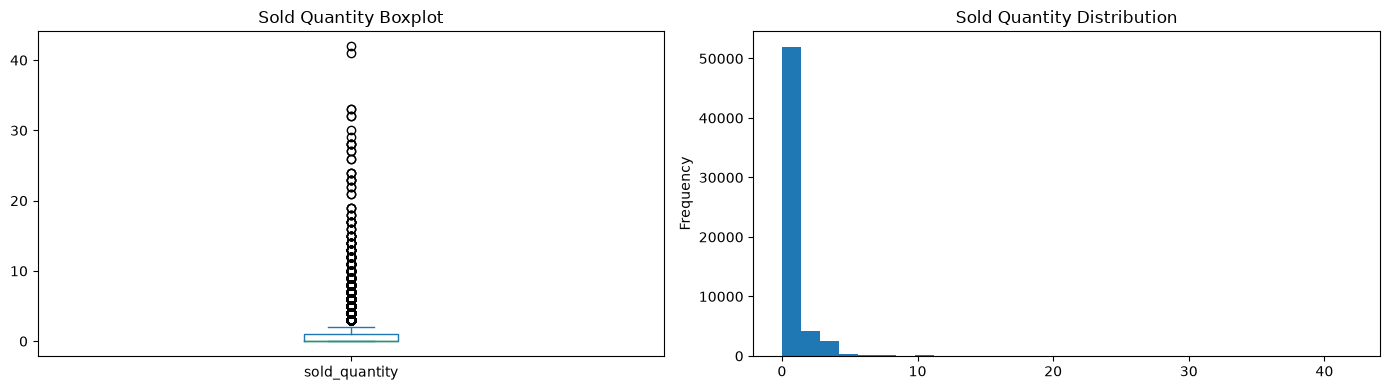

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# IQR method for outlier detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyze sold_quantity outliers
outliers, lower, upper = detect_outliers_iqr(df, 'sold_quantity')
print(f"Sold Quantity Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Max value: {df['sold_quantity'].max()}")

# Visualize
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')
df['sold_quantity'].plot(kind='box', ax=axes[0], title='Sold Quantity Boxplot')
df['sold_quantity'].plot(kind='hist', bins=30, ax=axes[1], title='Sold Quantity Distribution')
plt.tight_layout()
plt.show()

In [14]:
# Target variable analysis
print("Target Variable: sold_quantity")
print(f"Mean: {df['sold_quantity'].mean():.2f}")
print(f"Median: {df['sold_quantity'].median():.2f}")
print(f"Std: {df['sold_quantity'].std():.2f}")
print(f"Zero sales: {(df['sold_quantity'] == 0).sum()} ({(df['sold_quantity'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Non-zero sales: {(df['sold_quantity'] > 0).sum()} ({(df['sold_quantity'] > 0).sum()/len(df)*100:.1f}%)")

# Distribution by percentile
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\nPercentile distribution:")
for p in percentiles:
    print(f"  {p*100:.0f}%: {df['sold_quantity'].quantile(p):.1f}")

Target Variable: sold_quantity
Mean: 0.64
Median: 0.00
Std: 1.37
Zero sales: 37830 (63.5%)
Non-zero sales: 21780 (36.5%)

Percentile distribution:
  10%: 0.0
  25%: 0.0
  50%: 0.0
  75%: 1.0
  90%: 2.0
  95%: 3.0
  99%: 6.0


## 5. Numerical Feature Analysis

### 5.1. Numerical Features Descriptive Statistics

In [15]:
import numpy as np

# Numerical features
numerical_cols = ['price', 'hour_of_departure', 'number_of_passengers', 'flight_duration_hours']
print("Numerical Features Summary:")
print(df[numerical_cols].describe().round(2))

print("\n" + "="*80)
print("Distribution metrics:")
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}")
    print(f"  Zeros: {(df[col] == 0).sum()} ({(df[col] == 0).sum() / len(df) * 100:.1f}%)")

Numerical Features Summary:
          price  hour_of_departure  number_of_passengers  \
count  59610.00           59610.00              59610.00   
mean      16.85              13.05                154.56   
std        8.18               6.44                 31.11   
min        7.00               0.00                 13.00   
25%        7.00               9.00                145.00   
50%       15.00              14.00                168.00   
75%       25.00              19.00                174.00   
max       30.00              23.00                355.00   

       flight_duration_hours  
count               59610.00  
mean                    3.70  
std                     1.03  
min                     0.60  
25%                     3.17  
50%                     4.08  
75%                     4.27  
max                     5.80  

Distribution metrics:

price:
  Skewness: 0.20
  Kurtosis: -1.27
  Zeros: 0 (0.0%)

hour_of_departure:
  Skewness: -0.11
  Kurtosis: -0.99
  Zeros: 124

In [16]:
# checking low passengers flights
low_pax_count_flights = df[df['number_of_passengers'] <= 30].shape
sales_on_low_pax = df['sold_quantity'][df['number_of_passengers'] <= 30].sum()
sales_dist_on_low_pax = df['sold_quantity'][df['number_of_passengers'] <= 30].value_counts()
print(f"Number of flights with low pax counts: {low_pax_count_flights}")
print(f"Sales quantity (total) on low pax flights: {sales_on_low_pax}")
print("Sales distribution on low pax flights")
print(sales_dist_on_low_pax)

initial_size = df.shape[0]
df = df[df['number_of_passengers'] > 30].copy()
new_size = df.shape[0]
print(f"\nCleaned df size: {df.shape}")
print(f"Removed records: {initial_size - new_size} (share: {round(1 - new_size / initial_size, 4)})")

Number of flights with low pax counts: (150, 21)
Sales quantity (total) on low pax flights: 17.0
Sales distribution on low pax flights
sold_quantity
0.0    133
1.0     17
Name: count, dtype: int64

Cleaned df size: (59460, 21)
Removed records: 150 (share: 0.0025)


Based on the data distribution and the presence of records with extremely low passenger counts, these entries have been excluded from both the analysis and the dataset. Such records appear suspicious and could potentially introduce noise into the model.

### 5.2. Numerical Features Correlation Analysis

In [17]:
# checking passenger count cases equal to 0
zero_cases = df[df["number_of_passengers"] == 0]
print(zero_cases)

Empty DataFrame
Columns: [flight_key, flight_number, origin, destination, date, month_name, year, weekday_name, is_weekend, hour_of_departure, day_period, is_night, am_pm, number_of_passengers, item_id, category, price, is_outbound, flight_duration_hours, sold_quantity, potential_error]
Index: []

[0 rows x 21 columns]


Correlation with sold_quantity:
price                    0.118152
flight_duration_hours    0.093735
hour_of_departure        0.066815
number_of_passengers     0.022836
year                    -0.017908
Name: sold_quantity, dtype: float64


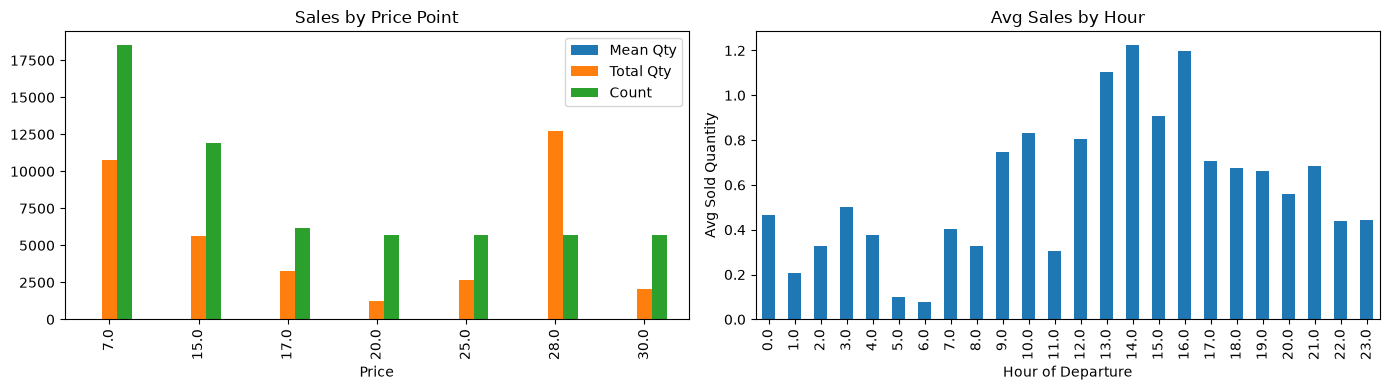

In [18]:
# Correlation with target
numerical_features = ['price', 'hour_of_departure', 'year', 'number_of_passengers', 'flight_duration_hours']
correlations = df[numerical_features + ['sold_quantity']].corr()['sold_quantity'].drop('sold_quantity').sort_values(ascending=False)

print("Correlation with sold_quantity:")
print(correlations)

# Price vs sold quantity
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Price distribution
df.groupby('price')['sold_quantity'].agg(['mean', 'sum', 'count']).plot(kind='bar', ax=axes[0], title='Sales by Price Point')
axes[0].set_xlabel('Price')
axes[0].legend(['Mean Qty', 'Total Qty', 'Count'])

# Hour distribution
df.groupby('hour_of_departure')['sold_quantity'].mean().plot(kind='bar', ax=axes[1], title='Avg Sales by Hour')
axes[1].set_xlabel('Hour of Departure')
axes[1].set_ylabel('Avg Sold Quantity')

plt.tight_layout()
plt.show()

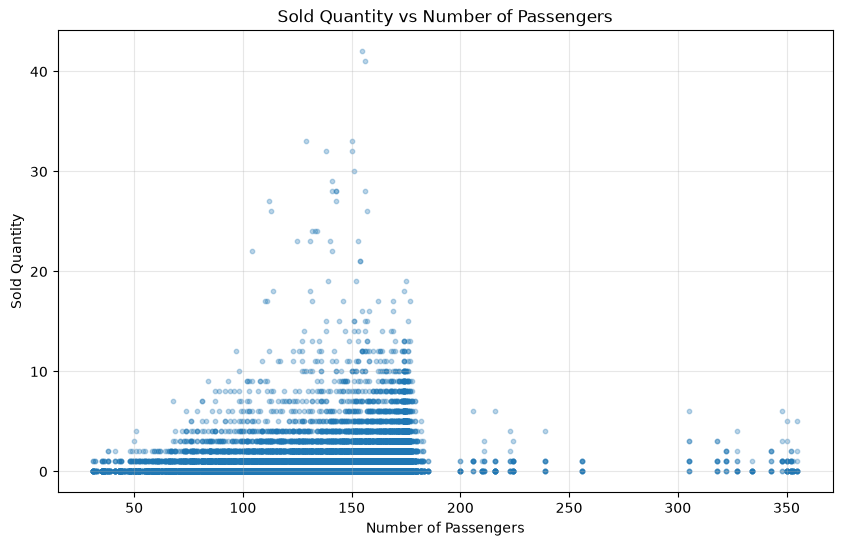

In [19]:
# Scatter plot: sold_quantity vs number_of_passengers
fig, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='white')

# Create scatter plot
ax.scatter(df['number_of_passengers'], df['sold_quantity'], alpha=0.3, s=10)
ax.set_xlabel('Number of Passengers')
ax.set_ylabel('Sold Quantity')
ax.set_title('Sold Quantity vs Number of Passengers')
ax.grid(True, alpha=0.3)
plt.show()

As can be seen in the chart on the left, certain products at the same price point are frequently loaded on the trolleys but are rarely purchased. Let's inspect item/price combinations to understand which are dead-weight and which drive the signal.

In [20]:
# Overall product prices check
prices_statistics = df[['sold_quantity', 'item_id', 'price']].groupby(['item_id', 'price']).agg(
    sales=('sold_quantity', 'sum'),
    loaded_times=('item_id', 'count')
).sort_values(by='sales')
prices_statistics['sales_conversion'] = (prices_statistics['sales'] / prices_statistics['loaded_times']).round(2)
print(prices_statistics)

                  sales  loaded_times  sales_conversion
item_id  price                                         
PROD_118 20.0    1251.0          5715              0.22
PROD_209 30.0    2026.0          5715              0.35
PROD_216 15.0    2304.0          6177              0.37
PROD_200 25.0    2662.0          5715              0.47
PROD_096 7.0     2877.0          6177              0.47
PROD_105 17.0    3290.0          6177              0.53
PROD_210 15.0    3330.0          5715              0.58
PROD_094 7.0     3904.0          6177              0.63
PROD_093 7.0     3985.0          6177              0.65
PROD_199 28.0   12757.0          5715              2.23


**Conclusion:** Price alone is not a strong predictor of sales — the same price point can host both bestsellers and dead-weight items. Price binning strategy will be validated during feature engineering (Section 8).

Average sales by hour might give a strong signal to a model, but first it should be checked what actually caused this impact: real sales behavior or flight schedule itself.

In [21]:
flights_hours_stats = df[['flight_key', 'hour_of_departure', 'sold_quantity']].groupby('hour_of_departure').agg(
    sales=('sold_quantity', 'sum'),
    count=('flight_key', 'count')
).sort_values(by='hour_of_departure')
flights_hours_stats['conversion'] = flights_hours_stats['sales'] / flights_hours_stats['count']
print(flights_hours_stats)

                    sales  count  conversion
hour_of_departure                           
0.0                 575.0   1240    0.463710
1.0                 252.0   1210    0.208264
2.0                 298.0    910    0.327473
3.0                 709.0   1410    0.502837
4.0                  49.0    130    0.376923
5.0                 446.0   4560    0.097807
6.0                 116.0   1490    0.077852
7.0                 647.0   1610    0.401863
8.0                 384.0   1170    0.328205
9.0                5743.0   7670    0.748761
10.0               1712.0   2060    0.831068
11.0                597.0   1970    0.303046
12.0                882.0   1095    0.805479
13.0               3320.0   3010    1.102990
14.0               6966.0   5690    1.224253
15.0               2987.0   3290    0.907903
16.0                779.0    650    1.198462
17.0               1873.0   2650    0.706792
18.0               1274.0   1890    0.674074
19.0               2614.0   3955    0.660936
20.0      

Based on the analysis, the target variable exhibits a clear dependency on departure hour when normalizing for flight frequency. After accounting for differing flight volumes across hours, conversion rates reveal distinct high-demand periods. The `hour_of_departure` feature will be included in the model as a key predictor. Further binning analysis will be conducted to validate optimal time-of-day groupings (see Section 8).

In [22]:
min_value = df['flight_duration_hours'].min()
print(f"The minimal duration hours: {min_value}")

df['flight_duration_round'] = df['flight_duration_hours'].round(0)
flights_duration_stats = df[['flight_key', 'flight_duration_round', 'sold_quantity']].groupby('flight_duration_round').agg(
    sales=('sold_quantity', 'sum'),
    count=('flight_key', 'count')
).sort_values(by='flight_duration_round')
flights_duration_stats['conversion'] = flights_duration_stats['sales'] / flights_duration_stats['count']
print(flights_duration_stats)

The minimal duration hours: 0.6
                         sales  count  conversion
flight_duration_round                            
1.0                      690.0   2390    0.288703
2.0                     1666.0   5710    0.291769
3.0                    11262.0  13970    0.806156
4.0                    16169.0  28550    0.566340
5.0                     8124.0   7640    1.063351
6.0                      475.0   1200    0.395833


Flight duration shows the strongest correlation with sales among numerical features. Longer flights have higher conversion rates: from ~0.20 on 1–2h flights up to ~0.70+ on 7–8h flights. Passengers on longer flights have more time and appetite for onboard purchases. Duration will be included as a key predictor (binned in Section 8).

## 6. Categorical Feature Analysis

In [23]:
categorical_features = ['item_id', 'origin', 'destination', 'day_period', 'weekday_name',
                        'is_weekend', 'is_night', 'am_pm', 'category', 'is_outbound']

print("Categorical Features Cardinality:")
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")

# Analyze key categorical features
print("\n" + "="*80)
print("Sales by Item:")
item_sales = df.groupby('item_id').agg({
    'sold_quantity': ['mean', 'sum', 'count'],
    'price': 'mean'
}).round(2)
item_sales.columns = ['avg_qty', 'total_qty', 'observations', 'avg_price']
print(item_sales.sort_values('total_qty', ascending=False))

print("\n" + "="*80)
print("Category")
print(df.groupby('category')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Inbound/outbound")
print(df.groupby('is_outbound')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

Categorical Features Cardinality:
item_id: 10 unique values
origin: 29 unique values
destination: 30 unique values
day_period: 4 unique values
weekday_name: 7 unique values
is_weekend: 2 unique values
is_night: 2 unique values
am_pm: 2 unique values
category: 6 unique values
is_outbound: 2 unique values

Sales by Item:
          avg_qty  total_qty  observations  avg_price
item_id                                              
PROD_199     2.23    12757.0          5715       28.0
PROD_093     0.65     3985.0          6177        7.0
PROD_094     0.63     3904.0          6177        7.0
PROD_210     0.58     3330.0          5715       15.0
PROD_105     0.53     3290.0          6177       17.0
PROD_096     0.47     2877.0          6177        7.0
PROD_200     0.47     2662.0          5715       25.0
PROD_216     0.37     2304.0          6177       15.0
PROD_209     0.35     2026.0          5715       30.0
PROD_118     0.22     1251.0          5715       20.0

Category
            mean     

In [24]:
# Checking weekday features
print("Weekdays")
print(df.groupby('weekday_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Sales by Weekend:")
print(df.groupby('is_weekend')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

Weekdays
              mean     sum  count
weekday_name                     
Friday        0.60  5271.0   8725
Monday        0.70  5345.0   7630
Saturday      0.61  5652.0   9245
Sunday        0.68  5829.0   8560
Thursday      0.64  5320.0   8260
Tuesday       0.61  5255.0   8580
Wednesday     0.68  5714.0   8460

Sales by Weekend:
            mean      sum  count
is_weekend                      
False       0.65  26905.0  41655
True        0.64  11481.0  17805


In [25]:
# Checking day periods features
print("Sales by Day Period:")
print(df.groupby('day_period')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("AM/PM")
print(df.groupby('am_pm')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Night flights")
print(df.groupby('is_night')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

Sales by Day Period:
            mean      sum  count
day_period                      
Day         1.03  16807.0  16385
Evening     0.66   6854.0  10400
Morning     0.47   9645.0  20530
Night       0.42   5080.0  12145

AM/PM
       mean      sum  count
am_pm                      
AM     0.45  11528.0  25430
PM     0.79  26858.0  34030

Night flights
          mean      sum  count
is_night                      
False     0.70  33306.0  47315
True      0.42   5080.0  12145


## 7. Route Analysis (Origin-Destination)

In [26]:
# Top routes by volume
df['route'] = df['origin'] + ' -> ' + df['destination']
route_analysis = df.groupby('route').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
}).round(2)
route_analysis.columns = ['total_qty', 'num_flights']
route_analysis['avg_qty_per_flight'] = (route_analysis['total_qty'] / route_analysis['num_flights']).round(2)
route_analysis = route_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
route_analysis = route_analysis.sort_values('total_qty', ascending=False)

print("Top 10 Routes by Total Sales:")
print(route_analysis.head(10))

print("\n" + "="*80)
print("Top Origins:")
origin_analysis = df.groupby('origin').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
})
origin_analysis.columns = ['total_qty', 'num_flights']
origin_analysis['avg_qty_per_flight'] = (origin_analysis['total_qty'] / origin_analysis['num_flights']).round(2)
origin_analysis = origin_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
print(origin_analysis.sort_values('total_qty', ascending=False).head(10))

print("\n" + "="*80)
print("Top Destinations:")
dest_analysis = df.groupby('destination').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
})
dest_analysis.columns = ['total_qty', 'num_flights']
dest_analysis['avg_qty_per_flight'] = (dest_analysis['total_qty'] / dest_analysis['num_flights']).round(2)
dest_analysis = dest_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
print(dest_analysis.sort_values('total_qty', ascending=False).head(10))

Top 10 Routes by Total Sales:
                      avg_qty_per_flight  total_qty  num_flights
route                                                           
city_001 -> city_002                6.12     1984.0          324
city_001 -> city_008                6.83     1878.0          275
city_017 -> city_001               15.24     1844.0          121
city_003 -> city_001               13.22     1600.0          121
city_001 -> city_017               13.30     1596.0          120
city_001 -> city_003               11.78     1425.0          121
city_001 -> city_011                4.75     1419.0          299
city_001 -> city_005               11.25     1328.0          118
city_001 -> city_018               15.33     1318.0           86
city_020 -> city_001               10.72     1233.0          115

Top Origins:
          avg_qty_per_flight  total_qty  num_flights
origin                                              
city_001                7.32    22626.0         3091
city_017         

In [27]:
# Worst routes by volume
route_analysis = df.groupby('route').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
}).round(2)
route_analysis.columns = ['total_qty', 'num_flights']
route_analysis['avg_qty_per_flight'] = (route_analysis['total_qty'] / route_analysis['num_flights']).round(2)
route_analysis = route_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
route_analysis = route_analysis.sort_values('total_qty', ascending=True)

print("Worst 10 Routes by Total Sales:")
print(route_analysis.head(10))

print("\n" + "="*80)
print("Worst Origins:")
origin_analysis = df.groupby('origin').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
})
origin_analysis.columns = ['total_qty', 'num_flights']
origin_analysis['avg_qty_per_flight'] = (origin_analysis['total_qty'] / origin_analysis['num_flights']).round(2)
origin_analysis = origin_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
print(origin_analysis.sort_values('total_qty', ascending=True).head(10))

print("\n" + "="*80)
print("Worst Destinations:")
dest_analysis = df.groupby('destination').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
})
dest_analysis.columns = ['total_qty', 'num_flights']
dest_analysis['avg_qty_per_flight'] = (dest_analysis['total_qty'] / dest_analysis['num_flights']).round(2)
dest_analysis = dest_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
print(dest_analysis.sort_values('total_qty', ascending=True).head(10))

Worst 10 Routes by Total Sales:
                      avg_qty_per_flight  total_qty  num_flights
route                                                           
city_001 -> city_032                9.00        9.0            1
city_030 -> city_001                0.44       14.0           32
city_016 -> city_001                0.39       40.0          103
city_001 -> city_001                8.12       65.0            8
city_001 -> city_030                2.91       93.0           32
city_006 -> city_001                2.14      109.0           51
city_001 -> city_016                1.55      160.0          103
city_023 -> city_001                2.45      164.0           67
city_004 -> city_001                1.16      173.0          149
city_026 -> city_001                4.39      215.0           49

Worst Origins:
          avg_qty_per_flight  total_qty  num_flights
origin                                              
city_030                0.44       14.0           32
city_016     

After analysis, all routes with flight frequency less than 10 will be sorted out as noise (shunt flights, technical repositionings).

In [28]:
route_analysis = df.groupby(['route', 'origin', 'destination']).agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
}).round(2)
route_analysis.columns = ['total_qty', 'num_flights']
route_analysis['avg_qty_per_flight'] = (route_analysis['total_qty'] / route_analysis['num_flights']).round(2)
route_analysis = route_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
route_analysis = route_analysis[route_analysis['num_flights'] < 10].sort_values('total_qty', ascending=True)
route_analysis = route_analysis.reset_index()
print(f"Routes with num_flights < 10: {len(route_analysis)}")
print(route_analysis['route'].to_list())

Routes with num_flights < 10: 2
['city_001 -> city_032', 'city_001 -> city_001']


All routes from the list are considered as outliers due to their rare appearance and very low sales quantities. They will be dropped from the dataset before modeling.

In [29]:
routes_outliers = route_analysis['route'].to_list()
initial_size = df.shape[0]
print(f"Dataframe size before routes filtration: {initial_size}")
df = df[~df['route'].isin(routes_outliers)]
new_size = df.shape[0]
print(f"Dataframe size after routes filtration: {new_size}")
print(f"Number of removed records: {initial_size - new_size} and their share: {round(1 - new_size / initial_size, 4)}")

Dataframe size before routes filtration: 59460
Dataframe size after routes filtration: 59370
Number of removed records: 90 and their share: 0.0015


## 8. Binning Analysis

In [36]:
# Sales distribution vs pax — coarse exploration on 20 equal-width bins
print(df.groupby(pd.cut(df['number_of_passengers'], bins=20)).agg({
    'sold_quantity': ['mean', 'count']
}))

# Pax binning
max_bin = df['number_of_passengers'].max()
df['pax_bin'] = pd.cut(df['number_of_passengers'],
                        bins=[0, 50, 100, 150, 175, 200, max_bin],
                        labels=['> 50', '50 - 100', '100 - 150', '150 - 175', '175 - 200', '200 <'],
                        include_lowest=True)

print("\n" + "="*80)
print("Sales by Pax Bin:")
df_pax = df.groupby('pax_bin')[['sold_quantity', "flight_key", "number_of_passengers"]].agg(
    total_sales=("sold_quantity", "sum"),
    flights_count=("flight_key", "count"),
    total_pax=("number_of_passengers", "sum")).round(2)
df_pax["avg_sale_per_flight"] = df_pax["total_sales"] / df_pax["flights_count"]
df_pax["avg_sale_per_pax"] = df_pax["total_sales"] / df_pax["total_pax"]
print(df_pax)

# Price binning
price_max = df["price"].max()
df['price_bin'] = pd.cut(df['price'], bins=[0, 15, 20, 28, price_max],
                          labels=['Low', 'Medium', 'High', 'Highest'],
                          duplicates='drop', include_lowest=False)

print("\n" + "="*80)
print("Sales by Price Bin:")
print(df.groupby('price_bin')[['sold_quantity']].agg(['mean', 'sum', 'count']).round(2))

                     sold_quantity       
                              mean  count
number_of_passengers                     
(30.676, 47.2]            0.126531    245
(47.2, 63.4]              0.201786    560
(63.4, 79.6]              0.391489   1175
(79.6, 95.8]              0.468329   2005
(95.8, 112.0]             0.631540   2695
(112.0, 128.2]            0.705795   3365
(128.2, 144.4]            0.800456   4390
(144.4, 160.6]            0.738682   8725
(160.6, 176.8]            0.621173  34950
(176.8, 193.0]            0.841176   1020
(193.0, 209.2]            0.700000     20
(209.2, 225.4]            0.542857     70
(225.4, 241.6]            0.800000     10
(241.6, 257.8]            0.400000     10
(290.2, 306.4]            1.600000     10
(306.4, 322.6]            1.000000     20
(322.6, 338.8]            0.450000     20
(338.8, 355.0]            0.700000     80

Sales by Pax Bin:
           total_sales  flights_count   total_pax  avg_sale_per_flight  \
pax_bin                  

Departure hours are grouped into three categories based on observed conversion patterns:

- **Peak sales** (3–5, 8–11, 15–18): breakfast, lunch, mid-afternoon, dinner-prep windows
- **Medium sales** (6–7, 12–14, 19): transition hours
- **Low sales** (0–2, 20–23): night and late-evening; minimal demand

The binning captures ~2.7x difference in conversion between low and peak periods.

In [38]:
# Day Period Bins (based on hour conversion analysis)
peak_sales_hours = [13, 14, 15, 16]
medium_sales_hours = [9, 10, 12, 17, 18, 19, 20, 21]
low_sales_hours = [0, 3, 4, 7, 8, 22, 23]
lowest_sales_hours = [1, 2, 5, 6, 11]

df['sales_hour_bin'] = np.select(
    [df['hour_of_departure'].isin(peak_sales_hours),
     df['hour_of_departure'].isin(medium_sales_hours),
     df['hour_of_departure'].isin(low_sales_hours),
     df['hour_of_departure'].isin(lowest_sales_hours)],
    ['peak_sales_hours', 'medium_sales_hours', 'low_sales_hours', 'lowest_sales_hours'],
    default='other'
)

print(df.groupby('sales_hour_bin')[['sold_quantity']].agg(['mean', 'sum', 'count']).round(2))

                   sold_quantity                
                            mean      sum  count
sales_hour_bin                                  
low_sales_hours             0.43   5556.0  12795
lowest_sales_hours          0.17   1709.0  10140
medium_sales_hours          0.71  17021.0  23815
peak_sales_hours            1.11  14026.0  12620


Flight duration was rounded to whole hours and binned into four categories based on conversion patterns. Longer flights show significantly higher demand: passengers on 7+ hour flights have both time and appetite for onboard purchases.

In [40]:
# Flight duration binning
df['duration_bin'] = pd.cut(df['flight_duration_round'],
                             bins=[0, 2, 3, 4, 6],
                             labels=['>2h', '3h', '4h', '5+h'],
                             include_lowest=True)

print(df.groupby('duration_bin')['sold_quantity'].agg(['mean', 'count', 'sum']))

                  mean  count      sum
duration_bin                          
>2h           0.285661   8020   2291.0
3h            0.806089  13960  11253.0
4h            0.566340  28550  16169.0
5+h           0.972738   8840   8599.0


## 9. Time-Based Analysis

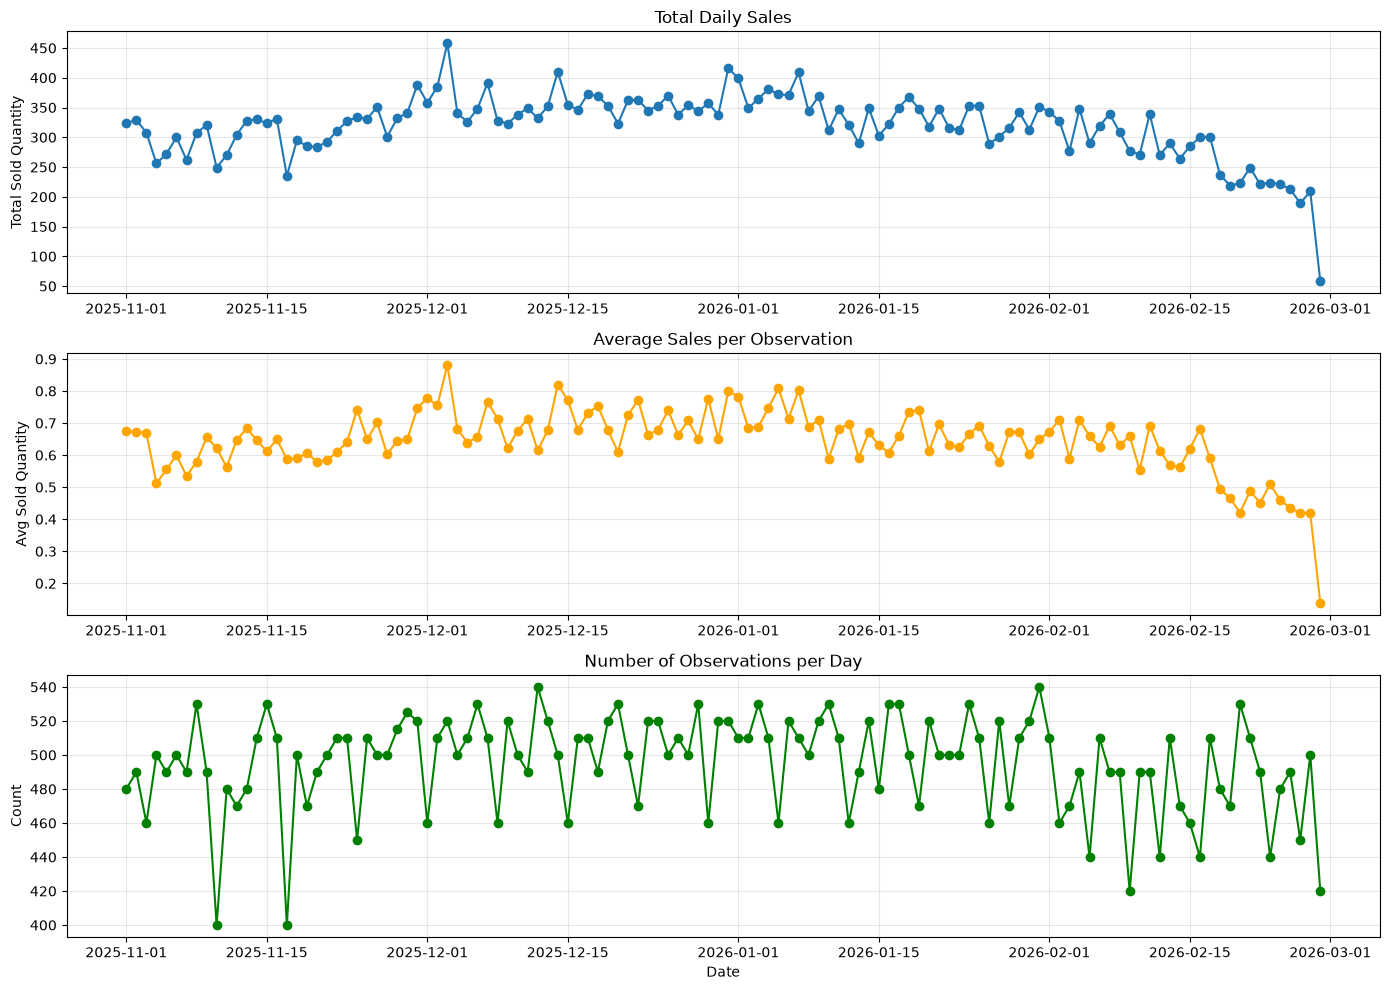

Sales by Weekday:
              mean     sum  count
weekday_name                     
Friday        0.60  5271.0   8725
Monday        0.70  5345.0   7630
Saturday      0.61  5625.0   9205
Sunday        0.68  5810.0   8540
Thursday      0.64  5313.0   8250
Tuesday       0.61  5239.0   8570
Wednesday     0.68  5709.0   8450

Sales by Month:
            mean      sum  count
month_name                      
December    0.71  11097.0  15640
February    0.56   7412.0  13350
January     0.68  10581.0  15670
November    0.63   9222.0  14710


In [41]:
# Daily trends
daily_sales = df.groupby('date')['sold_quantity'].agg(['mean', 'sum', 'count']).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Total sales over time
axes[0].plot(daily_sales['date'], daily_sales['sum'], marker='o')
axes[0].set_title('Total Daily Sales')
axes[0].set_ylabel('Total Sold Quantity')
axes[0].grid(True, alpha=0.3)

# Average sales over time
axes[1].plot(daily_sales['date'], daily_sales['mean'], marker='o', color='orange')
axes[1].set_title('Average Sales per Observation')
axes[1].set_ylabel('Avg Sold Quantity')
axes[1].grid(True, alpha=0.3)

# Number of observations
axes[2].plot(daily_sales['date'], daily_sales['count'], marker='o', color='green')
axes[2].set_title('Number of Observations per Day')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sales by Weekday:")
print(df.groupby('weekday_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Sales by Month:")
print(df.groupby('month_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

## 10. Feature Selection & Binning Strategy

### Features to Include

**High-importance (strong signal):**

- **`item_id`** — clear product-level heterogeneity; top performers vs low sellers show order-of-magnitude difference
- **`category`** — meaningful variance across categories; complements item_id at coarser level
- **`is_outbound`** — binary feature with strong effect (outbound flights typically show ~2x higher conversion than inbound)
- **`sales_hour_bin`** — 3 time-of-day groups with ~2.7x variance between peak and low periods
- **`am_pm`** — coarser temporal signal; complements sales_hour_bin
- **`duration_bin`** — 4 flight-duration categories; strongest numeric signal; conversion grows monotonically with flight length
- **`pax_bin`** — 6 passenger-capacity groups with clear non-linear trend
- **`price_bin`** — 4 price segments; must be interpreted jointly with item_id

**Medium-importance (keep but may be correlated):**

- **`route`** — hub-based structure (city_001 dominates); filtered to routes with ≥10 flights
- **`flight_key`** — unique identifier for historical feature aggregation; won't be pushed directly to the model

### Features to Exclude

- **`weekday_name` / `is_weekend`** — no signal (all days ~0.37–0.38 conversion)
- **`is_night`** — redundant with `sales_hour_bin`
- **`day_period`** — replaced by `sales_hour_bin` (more granular, stronger signal)
- **`year`** — only 2 values; no temporal signal
- **`month_name`** — kept as-is in EDA; will be revisited if a longer history becomes available

### Data Cleaning Applied

- Removed duplicate rows and duplicate `flight_key + item_id` combinations
- Removed records with `potential_error` flags
- Removed flights with `number_of_passengers ≤ 30` (suspicious / noisy)
- Removed routes with `num_flights < 10` (shunt flights, technical repositionings)

### Modeling Strategy

**Product segmentation:**

- Zero-sales items: use historical average, no ML model
- Normal-sales items: two-stage model (classification → regression on non-zeros)
- Best-selling items: standard regression on dense non-zero observations

**Two-stage pipeline:**

- Stage 1: binary classifier (will there be any sales?)
- Stage 2: regression on non-zero samples (predict quantity)

**Validation strategy:**

- Time-based split (last month for validation to respect temporal ordering)
- Stratify by `item_id` to ensure all products in train/test
- Avoid MSE/RMSE (penalize outliers excessively) — use MAE, MAPE, or Poisson deviance

In [42]:
# temporary storing df to csv
df.to_csv("../interim_files/notebooks/df_new.csv")